In [81]:
# Import pandas and numpy libraries

In [82]:
import pandas as pd
import numpy as np

In [83]:
# Create a dataframe for a .tsv file

In [84]:
df = pd.read_csv(r"C:\Users\24IT004\Desktop\AI-ML-VAC\assets\smsspamcollection.tsv", sep = "\t")

In [85]:
# Print the head of the dataframe - top preview of dataset - 5 rows

In [86]:
print(df.head())

  label                                            message  length  punct
0   ham  Go until jurong point, crazy.. Available only ...     111      9
1   ham                      Ok lar... Joking wif u oni...      29      6
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...     155      6
3   ham  U dun say so early hor... U c already then say...      49      6
4   ham  Nah I don't think he goes to usf, he lives aro...      61      2


In [87]:
# To find the length of dataframe

In [88]:
len(df)

5572

In [89]:
# To count missing values in each column

In [90]:
df.isnull().sum()

label      0
message    0
length     0
punct      0
dtype: int64

In [91]:
# To list out all columns in the dataframe

In [92]:
df.columns

Index(['label', 'message', 'length', 'punct'], dtype='object')

In [93]:
# To describe a column

In [94]:
df['label'].describe()

count     5572
unique       2
top        ham
freq      4825
Name: label, dtype: object

In [95]:
# To list out the unique values of column

In [96]:
df['label'].unique()

array(['ham', 'spam'], dtype=object)

In [97]:
# To print the value count of column

In [98]:
df['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [99]:
# Import plt from matplotlib.plt

In [100]:
import matplotlib.pyplot as plt
%matplotlib inline

In [101]:
# To draw a histogram

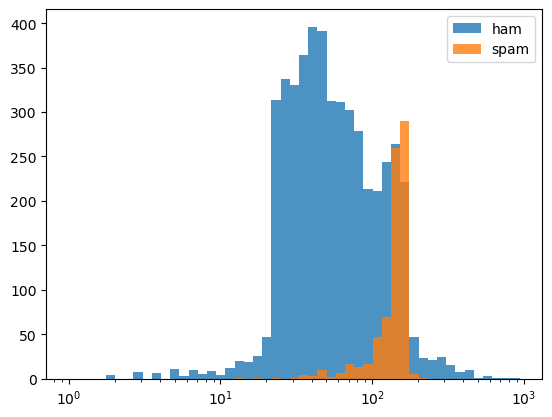

In [102]:
plt.xscale('log')
bins = 1.15 ** (np.arange(0, 50))

plt.hist(df[df['label'] == 'ham']['length'], bins=bins, alpha=0.8)
plt.hist(df[df['label'] == 'spam']['length'], bins=bins, alpha=0.8)

plt.legend(('ham', 'spam'))
plt.show()

In [103]:
# Install scikit learn package

In [104]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [105]:
# Import train_test_split from sklearn.model_selection

In [106]:
from sklearn.model_selection import train_test_split

In [107]:
# Creating features of X

In [118]:
x = df[['length','punct']]
y = df['label']

In [119]:
# Splitting the data into training data and test data

In [120]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.33,random_state=42)

In [121]:
# Print the shape (rows and columns) of the data

In [122]:
print("Training Data Shape: ", x_train.shape)
print("Testing Data Shape: ", x_test.shape)

Training Data Shape:  (3733, 2)
Testing Data Shape:  (1839, 2)


In [126]:
# Import LogisticRegression from sklearn.linear_model package

In [124]:
from sklearn.linear_model import LogisticRegression

In [143]:
# Create a Logistic Regression model using the lbfgs solver and train it using the training data

In [129]:
lr_model = LogisticRegression(solver = 'lbfgs')
print(lr_model.fit(x_train, y_train))

LogisticRegression()


In [ ]:
# Graphical UI display

In [131]:
lr_model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [145]:
# Import metrics from sklearn

In [144]:
from sklearn import metrics

In [146]:
# Predict class labels for the test data and generate the confusion matrix to evaluate model performance

In [147]:
predictions = lr_model.predict(x_test)
conf_matrix = metrics.confusion_matrix(y_test,predictions)

In [148]:
# Convert the confusion matrix into a labeled DataFrame for better readability and display it

In [137]:
df = pd.DataFrame(conf_matrix,index=['ham','spam'],columns=['ham','spam'])
print(df)

       ham  spam
ham   1547    46
spam   241     5


In [149]:
# Display the classification report showing precision, recall, F1-score, and accuracy of the model

In [138]:
print(metrics.classification_report(y_test,predictions))

              precision    recall  f1-score   support

         ham       0.87      0.97      0.92      1593
        spam       0.10      0.02      0.03       246

    accuracy                           0.84      1839
   macro avg       0.48      0.50      0.47      1839
weighted avg       0.76      0.84      0.80      1839



In [150]:
# Calculate and print the accuracy score of the model on the test data

In [139]:
print(metrics.accuracy_score(y_test,predictions))

0.843936922240348


In [151]:
# Import MultinomialNB from sklearn.naive_bayes

In [152]:
from sklearn.naive_bayes import MultinomialNB

In [153]:
# Create and train a Multinomial Naive Bayes model, then predict test data and display the confusion matrix

In [154]:
nb_model = MultinomialNB()

nb_model.fit(x_train,y_train)

predictions = nb_model.predict(x_test)
print(metrics.confusion_matrix(y_test,predictions))

[[1583   10]
 [ 246    0]]


In [155]:
# Display precision, recall, F1-score, and accuracy for each class using the classification report

In [156]:
print(metrics.classification_report(y_test,predictions))

              precision    recall  f1-score   support

         ham       0.87      0.99      0.93      1593
        spam       0.00      0.00      0.00       246

    accuracy                           0.86      1839
   macro avg       0.43      0.50      0.46      1839
weighted avg       0.75      0.86      0.80      1839



In [161]:
# Import SVC module from sklearn.svm package

In [162]:
from sklearn.svm import SVC

In [164]:
# Create a Support Vector Classifier with automatic gamma selection and train it using the training data

In [167]:
svc_model = SVC(gamma = 'auto')
svc_model.fit(x_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'auto'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [165]:
# Predict class labels for the test data and calculate the accuracy score of the SVC model

In [166]:
predictions = svc_model.predict(x_test)
metrics.accuracy_score(y_test, predictions)

0.8863512778684067